## Figure 2

Enviorment: env 1

In [1]:
import pandas as pd
import pickle
import os
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from scipy.stats import sem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import matplotlib as mpl
import re
import textwrap
import seaborn as sns

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import plot_avg_roc_from_dicts, plot_avg_pr_from_dicts

In [2]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

dpi = 300
font_size = 12
fig_size = 5

### load the data

In [3]:
# for the meta pkls
# 0: prediction
# 1: probs
# 2: f1
# 3: feature sets
# 4: ground truth labels
# 5: model params

In [4]:
pw1_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw1/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw2_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw2/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw3_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw3/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_3,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw4_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw4/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_8}_oof.pkl"
pw5_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw5/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw6_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw6/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_8}_oof.pkl"
pw7_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw7/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_32}_oof.pkl"
pw8_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw8/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_8}_oof.pkl"
pw9_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw9/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw10_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw10/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_32}_oof.pkl"

all_loo_paths = [pw1_5, pw2_5, pw3_5, pw4_5, pw5_5, pw6_5, pw7_5, pw8_5, pw9_5, pw10_5]

In [5]:
cu_all_probs = []
for i in range(10):
    full_path = all_loo_paths[i]
    with open(full_path, "rb") as f:
        data = pickle.load(f)
    cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [6]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

In [7]:
fmf_loo = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_cu.csv")

In [8]:
fmf_loo["fmf_prob"] = fmf_loo["pe_before_delivery_percent"] / 100
fmf_loo["id"] = [id.lower() for id in fmf_loo["patient_id"]]
fmf_loo = fmf_loo[["fmf_prob", "id"]]

In [9]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left")
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left")

In [10]:
# number subjects with predictions
len(cu_all_probs[~cu_all_probs[0].isna() | ~cu_all_probs[1].isna() | ~cu_all_probs[2].isna() | ~cu_all_probs[3].isna() | ~cu_all_probs[4].isna() | ~cu_all_probs[5].isna() |
    ~cu_all_probs[6].isna() | ~cu_all_probs[7].isna() | ~cu_all_probs[8].isna() | ~cu_all_probs[9].isna()])

1137

In [11]:
# number of pec cases with predictions
len(cu_all_probs[~cu_all_probs[0].isna() & ~cu_all_probs[1].isna() & ~cu_all_probs[2].isna() & ~cu_all_probs[3].isna() & ~cu_all_probs[4].isna() & ~cu_all_probs[5].isna() &
    ~cu_all_probs[6].isna() & ~cu_all_probs[7].isna() & ~cu_all_probs[8].isna() & ~cu_all_probs[9].isna()]) - 82

54

In [12]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    all_pec = pickle.load(f)

In [13]:
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]
sum(cu_all_probs["label"])

54

In [14]:
rename_dict = {}

for i in range(10):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

### Fig. 2A: ROC and PR plots

In [15]:
best_pp = 0.35
best_fp = 0.15
best_age = 37

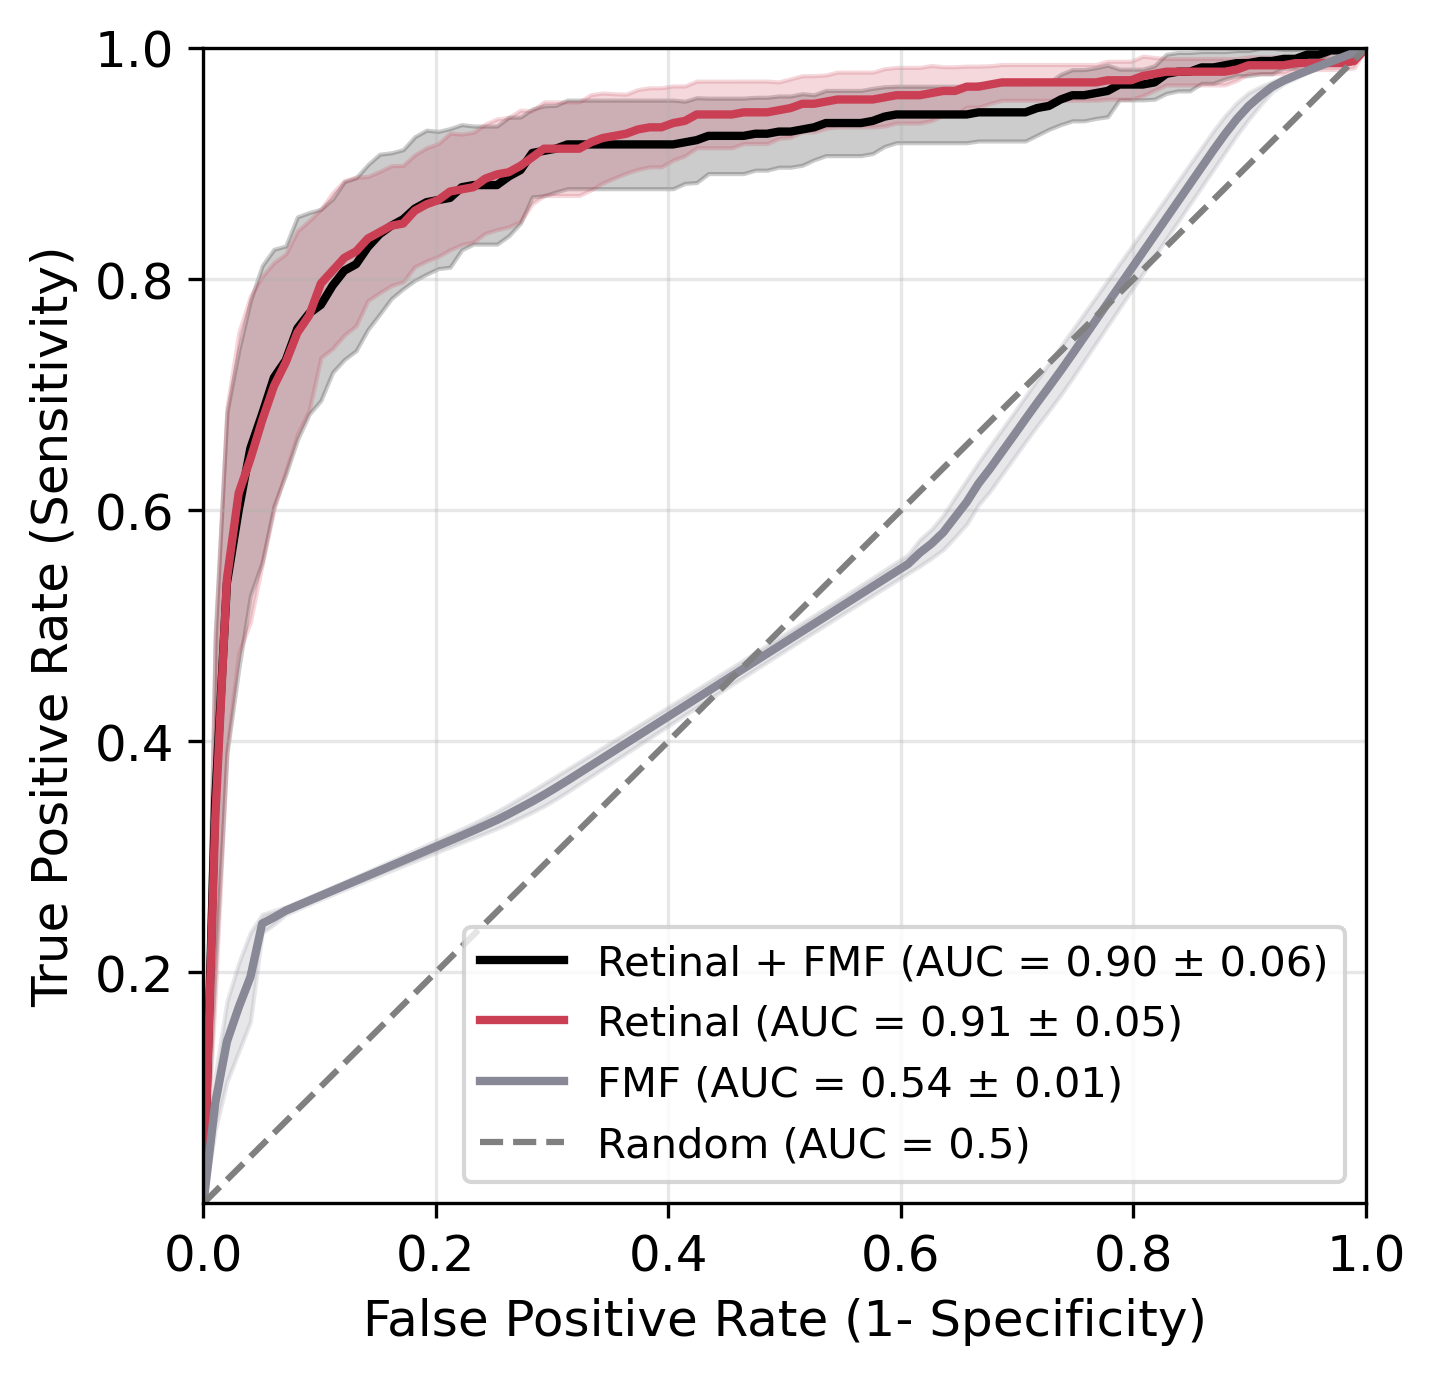

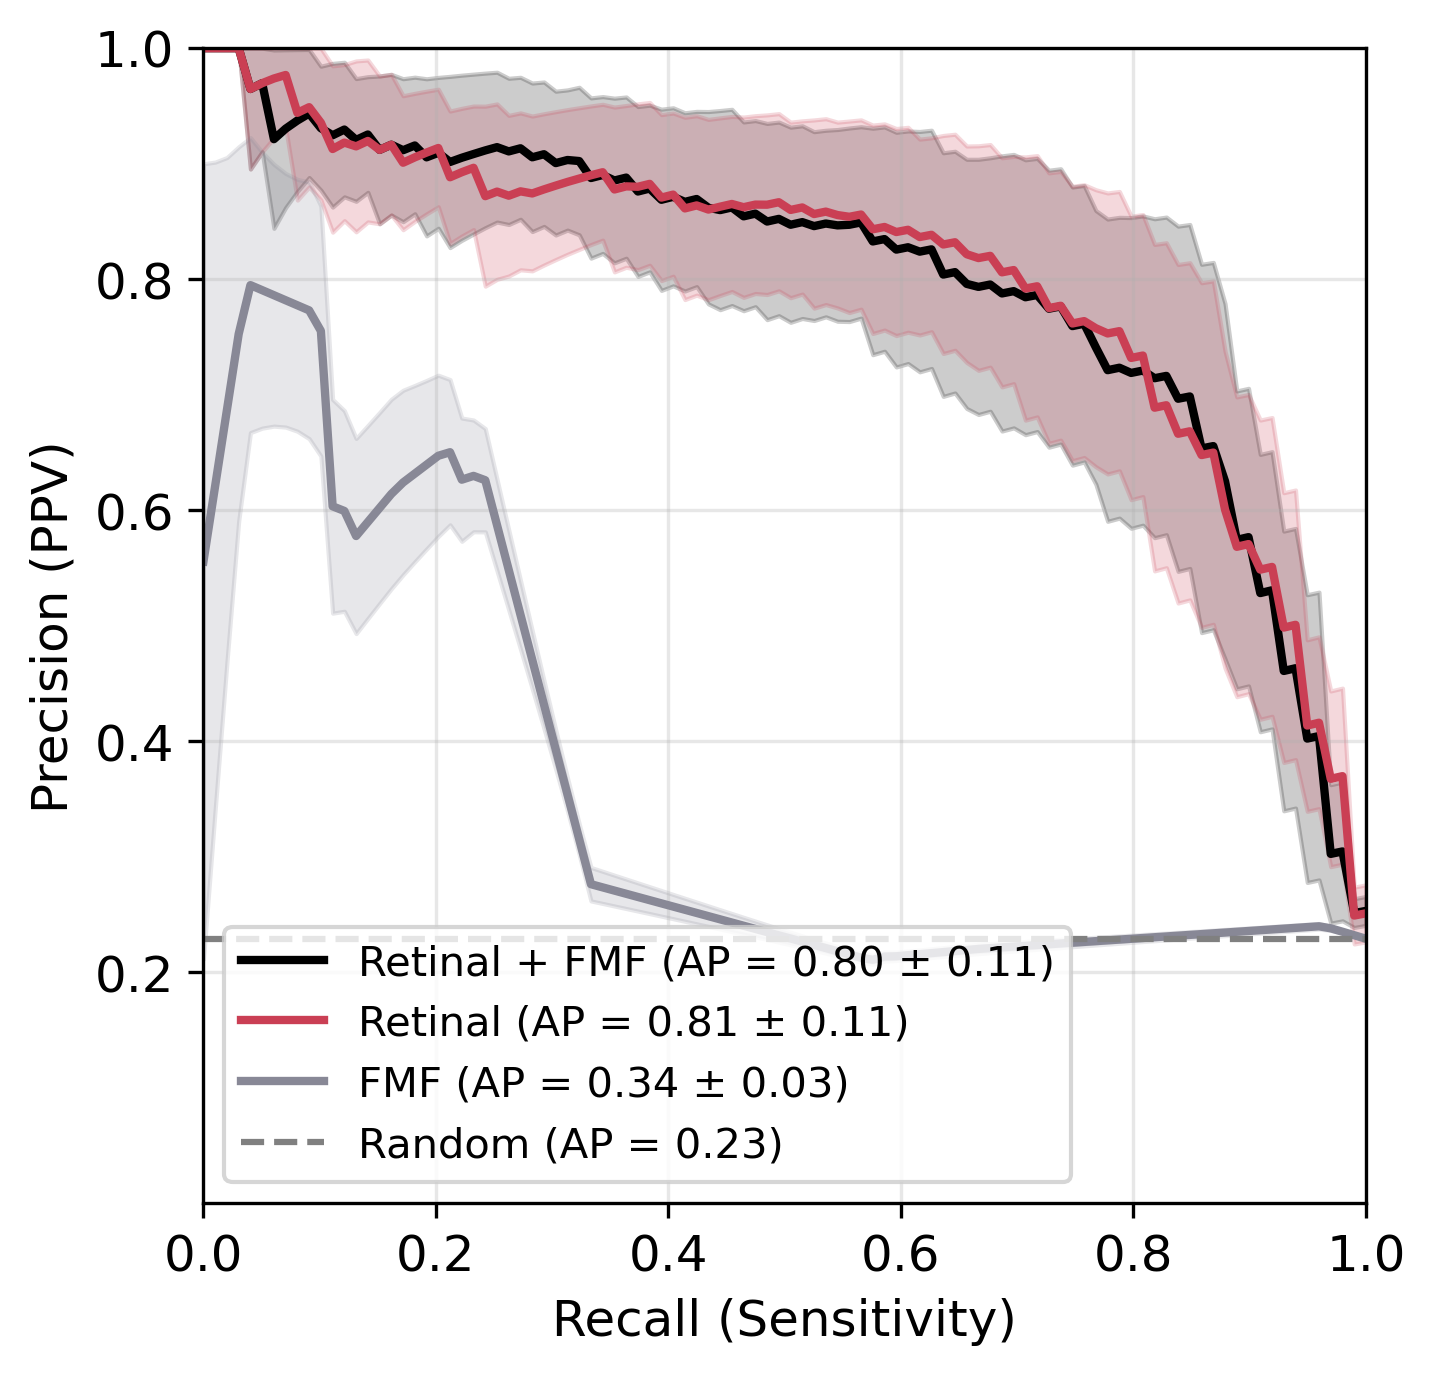

In [16]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# both
plot_avg_roc_from_dicts(cu_all_probs, title=f"Retinal + FMF", add_col=["fmf_prob"], plot=True, pw=10, color="black")

# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * best_pp + best_fp * (reweight["First Preg"] * (reweight["Age at enrollment"] > best_age).astype(int)))
plot_avg_roc_from_dicts(reweight, title=f"Retinal", add_col=cols, plot=True, pw=10, color="#CA3F54")

# fmf
reweight = cu_all_probs.copy()
for i in range(10):
    reweight.loc[~reweight[f"pw_{i + 1}"].isna(), f"pw_{i + 1}"] = 0
plot_avg_roc_from_dicts(reweight, title=f"FMF", add_col=["fmf_prob"], pw=10, color="#888896", rand=True)
plt.title("")
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_2/a_roc.pdf') 

plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# both
plot_avg_pr_from_dicts(cu_all_probs, title=f"Retinal + FMF", add_col=["fmf_prob"], plot=True, pw=10, color="black")

# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * best_pp + best_fp * (reweight["First Preg"] * (reweight["Age at enrollment"] > best_age).astype(int)))
plot_avg_pr_from_dicts(reweight, title=f"Retinal", add_col=cols, plot=True, pw=10, color="#CA3F54")

reweight = cu_all_probs.copy()
for i in range(10):
    reweight.loc[~reweight[f"pw_{i + 1}"].isna(), f"pw_{i + 1}"] = 0
plot_avg_pr_from_dicts(reweight, title=f"FMF", add_col=["fmf_prob"], pw=10, color="#888896", rand=True)
plt.title("")
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_2/a_pr.pdf') 

plt.show()

### Fig. 2B: bar charts

In [17]:
data_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data"

In [18]:
sf_cases = f"{data_path}/final_sf_20251028.pkl"
with open(sf_cases, "rb") as f:
    sf_cases = pickle.load(f)
nsf_cases = f"{data_path}/final_nsf_20251028.pkl"
with open(nsf_cases, "rb") as f:
    nsf_cases = pickle.load(f)
eope_cases = f"{data_path}/final_eope_20251017.pkl"
with open(eope_cases, "rb") as f:
    eope_cases = pickle.load(f)
lope_cases = f"{data_path}/final_lope_20251028.pkl"
with open(lope_cases, "rb") as f:
    lope_cases = pickle.load(f)
pec_cases = f"{data_path}/final_pec_20251017.pkl"
with open(pec_cases, "rb") as f:
    pec_cases = pickle.load(f)

In [19]:
pec_data = cu_all_probs[['pw_1', 'pw_2', 'pw_3', 'pw_4', 'pw_5', 'pw_6', 'pw_7', 'pw_8', 'pw_9', 'pw_10', 'label', 'id', "Past PEC", "First Preg", "Age at enrollment"]].copy()
pec_data.loc[:, "pec"] = [id in pec_cases for id in pec_data["id"]]
pec_data.loc[:, "sf"] = [id in sf_cases for id in pec_data["id"]]
pec_data.loc[:, "nsf"] = [id in nsf_cases for id in pec_data["id"]]
pec_data.loc[:, "eope"] = [id in eope_cases for id in pec_data["id"]]
pec_data.loc[:, "lope"] = [id in lope_cases for id in pec_data["id"]]

In [20]:
for i in range(1, 11):
    pec_data[f"pw_{i}"] = pec_data[f"pw_{i}"] + (reweight["Past PEC"] * best_pp + best_fp * (reweight["First Preg"] * (reweight["Age at enrollment"] > best_age).astype(int)))

In [21]:
cases = ["pec", "sf", "nsf", "eope", "lope"]
pw_results = None
thresh = 0.5
print(thresh)
for c in cases:
    for pw in range(1, 11):
        column = f"pw_{pw}"
        if "pec" == c:
            subset = pec_data[(~pec_data[column].isna())]
        else:
            subset = pec_data[(~pec_data[column].isna()) & ((pec_data[c] & pec_data["pec"]) | ~pec_data["pec"])]
        probabilities = np.array(list(subset[column]))
        predredictions = probabilities > thresh
        grounds = np.array(list(subset["label"]))

        f1 = f1_score(grounds, predredictions)
        tn, fp, fn, tp = confusion_matrix(grounds, predredictions).ravel().tolist()
        f1 = f1_score(grounds, predredictions)
        tpr = tp / (tp + fn) if (tp + fn) else 0
        fpr = fp / (fp + tn) if (fp + tn) else 0
        fnr = fn / (fn + tp) if (fn + tp) else 0
        tnr = tn / (tn + fp) if (tn + fp) else 0
        ppv = tp / (tp + fp) if (tp + fp) else 0
        npv = tn / (tn + fn) if (tn + fn) else 0
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0
        auc_stat = roc_auc_score(grounds, probabilities)
        metric_df = pd.DataFrame({
            "cases": [c], "AUC": auc_stat, "PPV": ppv, "NPV": npv, "TPR": tpr, "FPR": fpr,
            'adjusted ppv': tpr * 0.04 / (tpr * 0.04 + (fpr) * (1 - 0.04)) if (tpr * 0.04 + (fpr) * (1 - 0.04)) else 0,
            'adjusted npv': tnr * (1 - 0.04) / (tnr * (1 - 0.04) + fnr * 0.04), "F1": f1
        })
        if pw_results is None:
            pw_results = metric_df
        else:
            pw_results = pd.concat([pw_results, metric_df])
pw_results = pw_results.groupby("cases").mean()
pw_results["order"] = [3, 4, 2, 0, 1]
pw_results = pw_results.sort_values("order")
pw_results.round(2)

0.5


,AUC,PPV,NPV,TPR,FPR,adjusted ppv,adjusted npv,F1,order
cases,,,,,,,,,
pec,0.91,0.75,0.93,0.78,0.08,0.32,0.99,0.76,0
sf,0.90,0.68,0.95,0.77,0.08,0.32,0.99,0.72,1
nsf,0.92,0.49,0.98,0.80,0.08,0.32,0.99,0.60,2
eope,0.93,0.55,0.98,0.84,0.08,0.33,0.99,0.66,3
lope,0.89,0.65,0.95,0.75,0.08,0.31,0.99,0.69,4


In [22]:
n_values = [sum(pec_data["pec"]), sum(pec_data["sf"]), sum(pec_data["nsf"]), sum(pec_data["eope"]), sum(pec_data["lope"])]

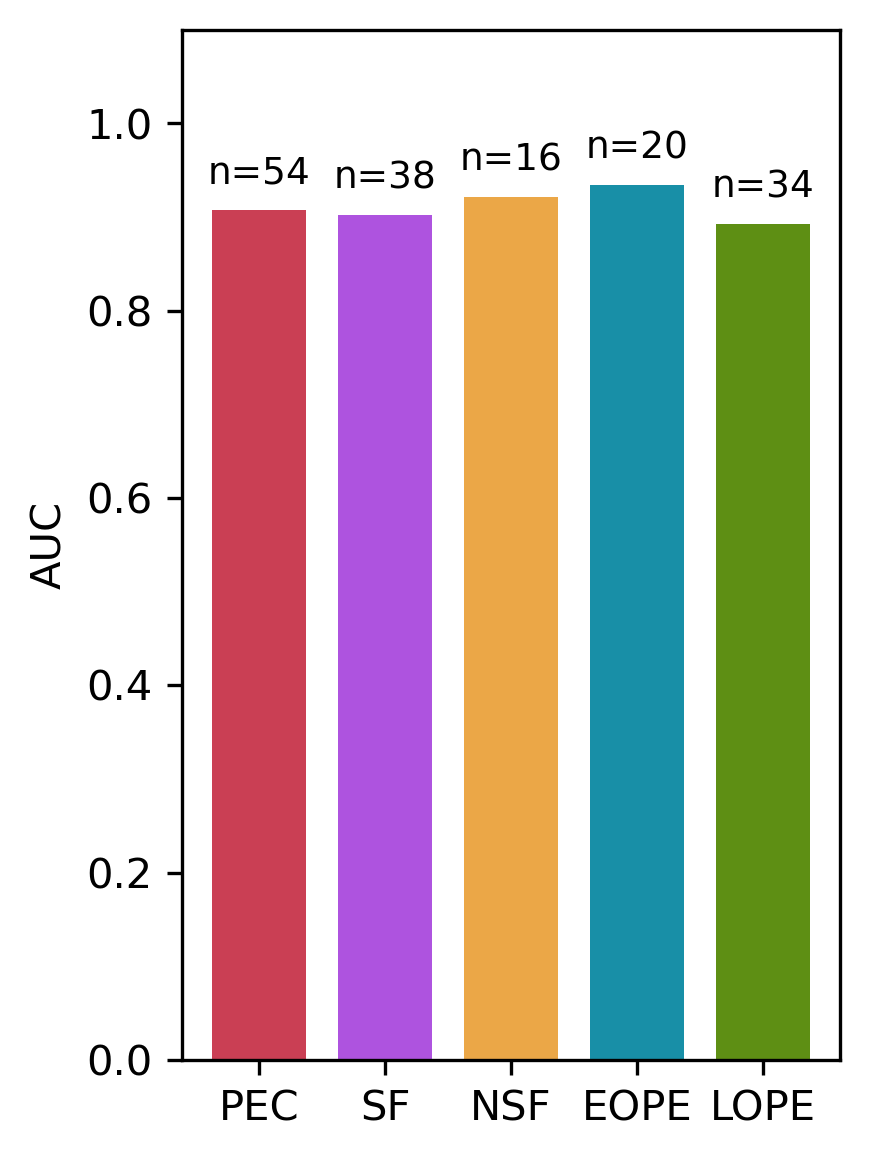

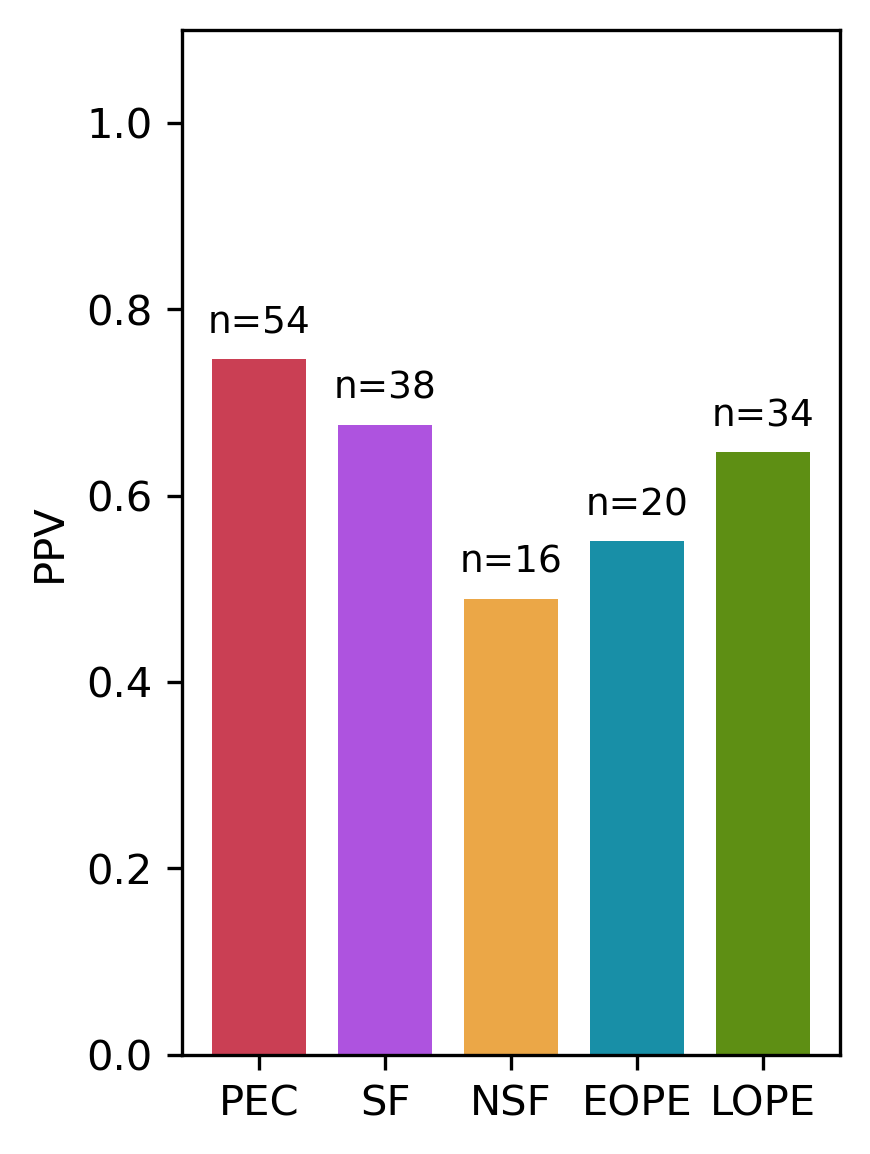

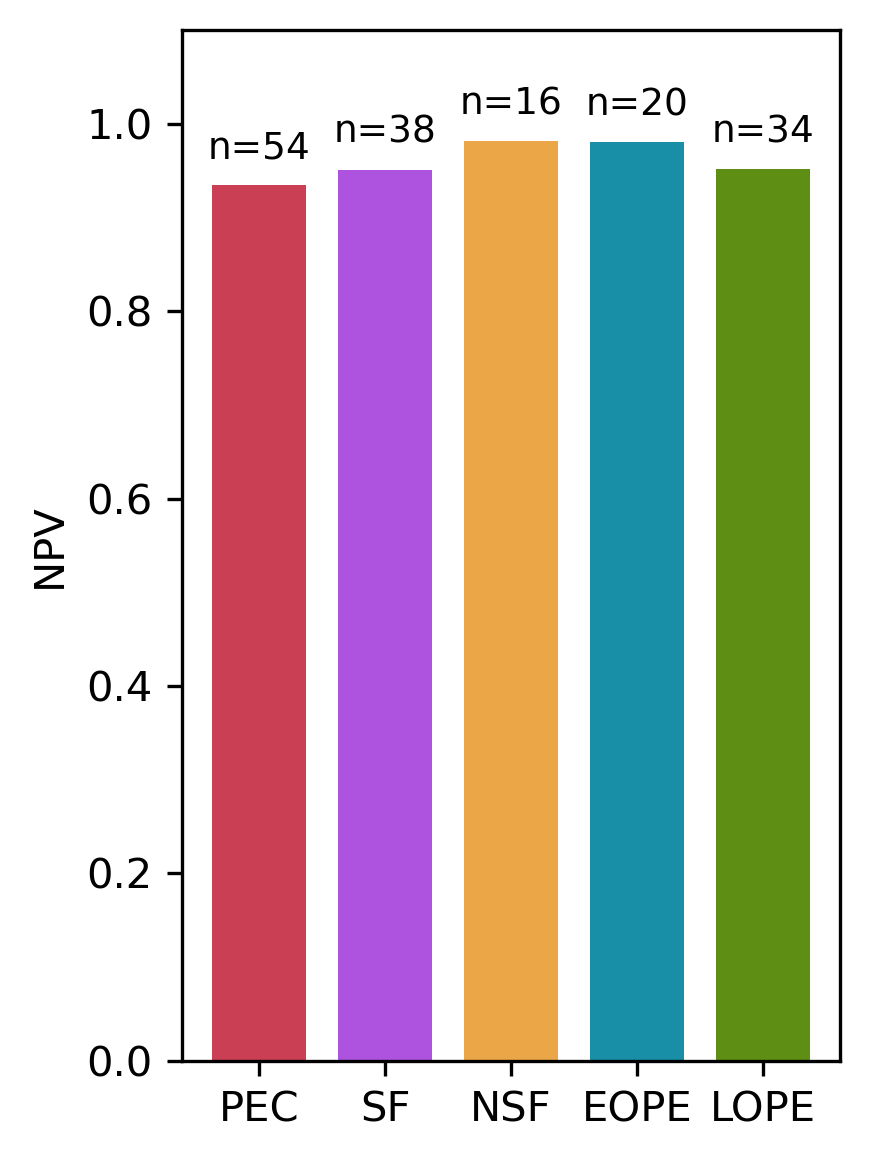

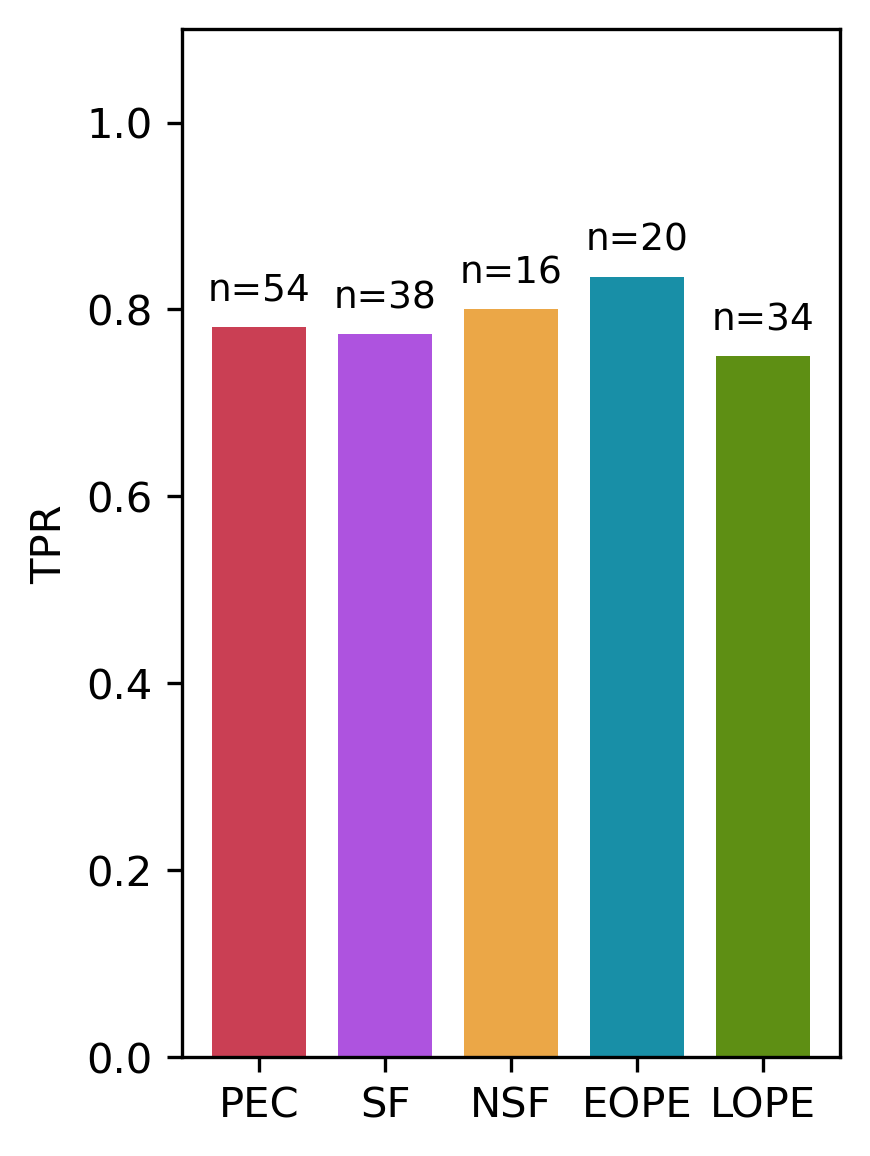

In [23]:
# BAR PLOTS
for col in pw_results.columns:
    if col in ["order", "FPR", "cases", "adjusted ppv", "adjusted npv", "F1"]:
        continue
    plt.figure(figsize=(3, 4), dpi=dpi)
    bars = plt.bar([i.upper() for i in pw_results.index], pw_results[col], width=0.75, color=["#CA3F54", "#AE53DF", "#EBA747", "#188FA7", "#5E8F14"])
    for bar, n_value in zip(bars, n_values):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.02,
            f'n={n_value}',
            ha='center',
            va='bottom',
            fontsize=9
        )
    plt.ylabel(col)
    plt.tight_layout()
    plt.ylim(0,1.1)
    plt.savefig(f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_2/b_{col.lower()}.pdf') 

    plt.show()

### Fig. 2C: feature importance

In [24]:
def wrap_labels(labels, max_width=12):
    return ['\n'.join(textwrap.wrap(label, max_width)) for label in labels]

In [25]:
pw1_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw1/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw2_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw2/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw3_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw3/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_3,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw4_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw4/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_8}_oof.pkl"
pw5_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw5/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw6_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw6/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_8}_oof.pkl"
pw7_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw7/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_32}_oof.pkl"
pw8_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw8/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_8}_oof.pkl"
pw9_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw9/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw10_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw10/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_32}_oof.pkl"

pw_5_paths = [pw1_5, pw2_5, pw3_5, pw4_5, pw5_5, pw6_5, pw7_5, pw8_5, pw9_5, pw10_5]

In [26]:
for path in pw_5_paths:
    with open(path, "rb") as f:
        data = pickle.load(f)
        break

In [27]:
bl_clean = {
    'graph_feats_mixed_feat_set__Logistic_Regression': 'Mixed LR',
    'tda_outward_Random_Forest': 'TDA Outward RF',
    'graph_feats_ratio_feats__Logistic_Regression': 'Ratio LR',
    'graph_feats_tort_cols__Logistic_Regression': 'Tortuosity LR',
    'graph_feats_tort_cols__XGBoost': 'Tortuosity XGB',
    'tda_flooding_XGBoost': 'TDA Flooding XGB',
    'graph_feats_mixed_feat_set__Random_Forest': 'Mixed RF',
    'tda_inward_Random_Forest': 'TDA Inward RF',
    'processed_dan_tree_feats_nest_num_feats_dan__Logistic_Regression': 'Nesting Number LR',
    'tree_feats_len_bottom_XGBoost': 'Inferior Topological Length Shift XGB',
    'graph_feats_tort_cols__Random_Forest': 'Tortuosity RF',
    'graph_feats_complexity_cols__Logistic_Regression': 'Complexity LR',
    'tda_flooding_Logistic_Regression': 'TDA Flooding LR',
    'old_tree_feats_diameter_XGBoost': 'Vessel Thickness Shift XGB',
    'tree_feats_len_real_bottom_Logistic_Regression': 'Weighted Inferior Topological Length Shift LR',
    'graph_feats_topo_lengths_feats__Logistic_Regression': 'Topological Length LR',
    'graph_feats_tree_feats__Random_Forest': 'Tree RF',
    'graph_feats_topo_lengths_feats__XGBoost': 'Topological Length XGB',
    'graph_feats_complexity_cols__Random_Forest': 'Complexity RF',
    'tda_flooding_Random_Forest': 'TDA Flooding RF',
    'tda_vr_Logistic_Regression': 'TDA VR LR',
    'old_tree_feats_assymetry_Logistic_Regression': 'Asymmetry Shift LR',
    'tree_feats_len_real_top_XGBoost': 'Weighted Superior Topological Length Shift XGB',
    'tda_outward_XGBoost': 'TDA Outward XGB',
    'processed_dan_tree_feats_angle_feats_dan__XGBoost': 'Angles XGB',
    'tree_feats_len_real_bottom_Random_Forest': 'Weighted Inferior Topological Length Shift RF',
    'graph_feats_geom_feats__Logistic_Regression': 'Geometry LR',
    "graph_feats_geom_feats__XGBoost": "Geometry XGB",
    'graph_feats_mixed_feat_set__XGBoost': 'Mixed XGB',
    'tda_outward_Logistic_Regression': 'TDA Outward LR',
    'graph_feats_graph_cols__Random_Forest': 'Graph RF',
    'box_counting_df_Logistic_Regression': 'Box Counting LR',
    'graph_feats_graph_cols__XGBoost': 'Graph XGB',
    'graph_feats_complexity_cols__XGBoost': 'Complexity XGB',
    'tree_feats_conductivity_bottom_Random_Forest': 'Inferior Vessel Thickness Shift RF',
    'processed_dan_tree_feats_angle_feats_dan__Logistic_Regression': 'Angles LR',
    'processed_dan_tree_feats_angle_feats_dan__Random_Forest': 'Angles RF',
    'graph_feats_tree_feats__XGBoost': 'Tree XGB',
    'processed_dan_tree_feats_topo_lengths_feats_dan__Logistic_Regression': 'Topological Length (whole graph) LR',
    'tda_vr_Random_Forest': 'TDA VR RF',
    'tree_feats_conductivity_bottom_XGBoost': 'Inferior Vessel Thickness Shift XGB',
    'processed_dan_tree_feats_nest_num_feats_dan__Random_Forest': 'Nesting Number RF',
    'old_tree_feats_assymetry_XGBoost': 'Asymmetry Shift XGB',
    'graph_feats_tree_feats__Logistic_Regression': 'Tree LR',
    'tree_feats_conductivity_top_Random_Forest': 'Superior Vessel Thickness Shift RF',
    'graph_feats_bifurc_ratio_feats__XGBoost': 'Bifurcation Ratio XGB',
    'tda_inward_Logistic_Regression': 'TDA Inward LR',
    'graph_feats_topo_lengths_feats__Random_Forest': 'Topological Length RF',
    'tree_feats_conductivity_top_XGBoost': 'Superior Vessel Thickness Shift XGB',
    'graph_feats_bifurc_ratio_feats__Logistic_Regression': 'Bifurcation Ratio LR',
    'tree_feats_len_bottom_Random_Forest': 'Inferior Topological Length Shift RF',
    'graph_feats_ratio_feats__XGBoost': 'Ratio XGB',
    'tda_inward_XGBoost': 'TDA Inward XGB',
    'box_counting_df_XGBoost': 'Box Counting XGB',
    'tree_feats_len_bottom_Logistic_Regression': 'Inferior Topological Length Shift LR',
    'graph_feats_ratio_feats__Random_Forest': 'Ratio RF',
    'graph_feats_std_feats__XGBoost': 'STD XGB',
    'old_tree_feats_assymetry_Random_Forest': 'Asymmetry Shift RF',
    'graph_feats_cum_size_dist_feats__Logistic_Regression': 'Cum. Size Dist. LR',
    'box_counting_df_Random_Forest': 'Box Counting RF',
    'tree_feats_len_top_XGBoost': 'Superior Topological Length Shift XGB',
    'old_tree_feats_len_Random_Forest': 'Topological Length Shift RF',
    'tree_feats_len_real_top_Logistic_Regression': 'Weighted Superior Topological Length Shift LR',
    'tree_feats_conductivity_top_Logistic_Regression': 'Superior Vessel Thickness Shift LR',
    'graph_feats_conductivity_feats__Logistic_Regression': 'Vessel Thickness LR',
    'processed_dan_tree_feats_topo_lengths_feats_dan__XGBoost': 'Topological Length (whole graph) XGB',
    'graph_feats_std_feats__Logistic_Regression': 'STD LR',
    'graph_feats_asym_feats__XGBoost': 'Asymmetry XGB',
    'graph_feats_graph_cols__Logistic_Regression': 'Graph LR',
    'tree_feats_len_real_bottom_XGBoost': 'Weighted Inferior Topological Length Shift XGB',
    'graph_feats_bifurc_ratio_feats__Random_Forest': 'Bifurcation Ratio RF',
    'tree_feats_len_top_Random_Forest': 'Superior Topological Length Shift RF',
    'tree_feats_len_top_Logistic_Regression': 'Superior Topological Length Shift LR',
    'processed_dan_tree_feats_nest_num_feats_dan__XGBoost': 'Nesting Number XGB',
    'tree_feats_len_real_top_Random_Forest': 'Weighted Superior Topological Length Shift LR',
    'graph_feats_asym_feats__Logistic_Regression': 'Asymmetry LR',
    'old_tree_feats_len_Logistic_Regression': 'Topological Length Shift LR',
    'graph_feats_strahler_order_feats__Logistic_Regression': 'Strahler Order LR',
    'graph_feats_strahler_order_feats__XGBoost': 'Strahler Order XGB',
    "graph_feats_cum_size_dist_feats__XGBoost": 'Cum. Size Dist. XGB',
    "graph_feats_geom_feats__Random_Forest": 'Geometry RF',
    "graph_feats_strahler_order_feats__Random_Forest": 'Strahler Order RF',
    "tree_feats_conductivity_bottom_Logistic_Regression": 'Inferior Vessel Thickness Shift LR',
    "graph_feats_std_feats__Random_Forest":  'STD RF',
    "graph_feats_nest_num_feats__Random_Forest": "Nest Num RF",
    "graph_feats_cum_size_dist_feats__Random_Forest": 'Cum. Size Dist. RF',
    "graph_feats_nest_num_feats__Logistic_Regression": "Nest Num LR",
    "graph_feats_nest_num_feats__XGBoost": "Nest Num XGB",
    "tda_vr_XGBoost": "TDA VR XGB",
    "graph_feats_conductivity_feats__XGBoost": 'Vessel Thickness XGB',
    "processed_dan_tree_feats_topo_lengths_feats_dan__Random_Forest": 'Topological Length (whole graph) RF',
    "graph_feats_conductivity_feats__Random_Forest": 'Vessel Thickness RF',
    "graph_feats_geom_feats__XGBoost": "Geometry XGB",
    "old_tree_feats_diameter_Logistic_Regression": "Vessel Thickness Shift LR"
}

In [28]:
def get_test_feat_imp(imp_df, save_path, n_pop=10, feats=8):
    """
    get the feature importance heatmaps
    """
    
    pw_cols = [f"PW{i}" for i in range(1, n_pop + 1)]
    
    heatmap_raw = pd.DataFrame(index=imp_df.index)
    for i in range(1, n_pop + 1):
        if ('imp', i) in imp_df.columns:
            heatmap_raw[f"PW{i}"] = imp_df[('imp', i)].values
        elif i in imp_df.columns:
            heatmap_raw[f"PW{i}"] = imp_df[i].values
    
    heatmap_raw.index = pd.Series(heatmap_raw.index).map(bl_clean).tolist()
    heatmap_raw = heatmap_raw.astype(float)
    
    heatmap_raw = heatmap_raw.fillna(0)
    
    def get_base_feature(feat_name):
        """Strip trailing model type suffix like LR, RF, XGB to get the base feature name."""
        match = re.match(r'^(.*?)\s+(LR|RF|XGB)$', feat_name)
        if match:
            return match.group(1), match.group(2)
        return feat_name, ''
    
    base_names = []
    model_types_list = []
    for feat in heatmap_raw.index:
        base, model = get_base_feature(feat)
        base_names.append(base)
        model_types_list.append(model)
    
    heatmap_raw['base_feature'] = base_names
    heatmap_raw['model_type_suffix'] = model_types_list
    
    # group by base feature and sum importances
    agg_df = heatmap_raw.groupby('base_feature')[pw_cols].sum()
    
    # build the display name with model types in parentheses
    model_suffixes_per_base = heatmap_raw.groupby('base_feature')['model_type_suffix'].apply(
        lambda x: sorted(set(s for s in x if s != ''))
    )
    
    display_names = {}
    for base in agg_df.index:
        suffixes = model_suffixes_per_base.get(base, [])
        if suffixes:
            display_names[base] = f"{base} ({'/'.join(suffixes)})"
        else:
            display_names[base] = base
    
    agg_df.index = [display_names[base] for base in agg_df.index]

    agg_df[pw_cols] = agg_df[pw_cols].div(agg_df[pw_cols].sum(axis=0), axis=1)
    
    # sort by prevalence (number of non-zero PWs), then by mean importance as tiebreaker
    agg_df['prevalence'] = (agg_df[pw_cols] > 0).sum(axis=1)
    agg_df['mean_imp'] = agg_df[pw_cols].mean(axis=1)
    agg_df = agg_df.sort_values(['prevalence', 'mean_imp'], ascending=[False, False])
    agg_df = agg_df.drop(columns=['prevalence', 'mean_imp'])

    agg_df = agg_df.head(feats)
    
    # plot heatmap
    fig, ax = plt.subplots(figsize=(8, max(5, len(agg_df) * 0.4)), dpi=dpi)
    cbar_kws = {'label': 'Meta-Learner Base Learner Importance'}
    
    sns.heatmap(
        agg_df,
        annot=True,
        fmt=".2f",
        cmap="rocket_r",
        linewidths=0.5,
        ax=ax,
        cbar_kws=cbar_kws,
        mask=(agg_df == 0),
        vmin=0,
        annot_kws={"size": 8}
    )
    
    ax.set_ylabel("Feature Set", fontsize=8)
    ax.tick_params(axis='y', labelsize=8, pad=150)
    ax.set_yticklabels(
        wrap_labels(list(agg_df.index), 30), 
        rotation=0, 
        ha='left',
        fontsize=8
    )
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(8)
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_xlabel("Control Group", fontsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [29]:
all_data = []
pw = 1
for path in pw_5_paths:
    all_pw_data = pd.DataFrame({"bl": [], "pw": []})
    with open(path, "rb") as f:
        data = pickle.load(f)
        for i in range(len(list(data[6].keys()))):
            test_i = pd.DataFrame({"pw": pw, "bl": data[3][i].values, f"imp_{list(data[6].keys())[i]}": data[6][list(data[6].keys())[i]].feature_importances_})
            all_pw_data = all_pw_data.merge(test_i, on=["bl", "pw"], how="outer")
    pw += 1
    all_pw_data = all_pw_data.fillna(0)
    all_data.append(all_pw_data)
all_data = pd.concat(all_data)
test_data = all_data[["pw", "bl"]]
test_data.loc[:, "imp"] = all_data[list(set(list(all_data.columns)) - set(["pw", "bl"]))].sum(axis=1)
test_pivot = test_data.pivot_table(test_data, index="bl", aggfunc="sum", columns="pw")

/gpfs/data/oermannlab/users/ca3261/.conda/envs/env1/lib/python3.7/site-packages/pandas/core/indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


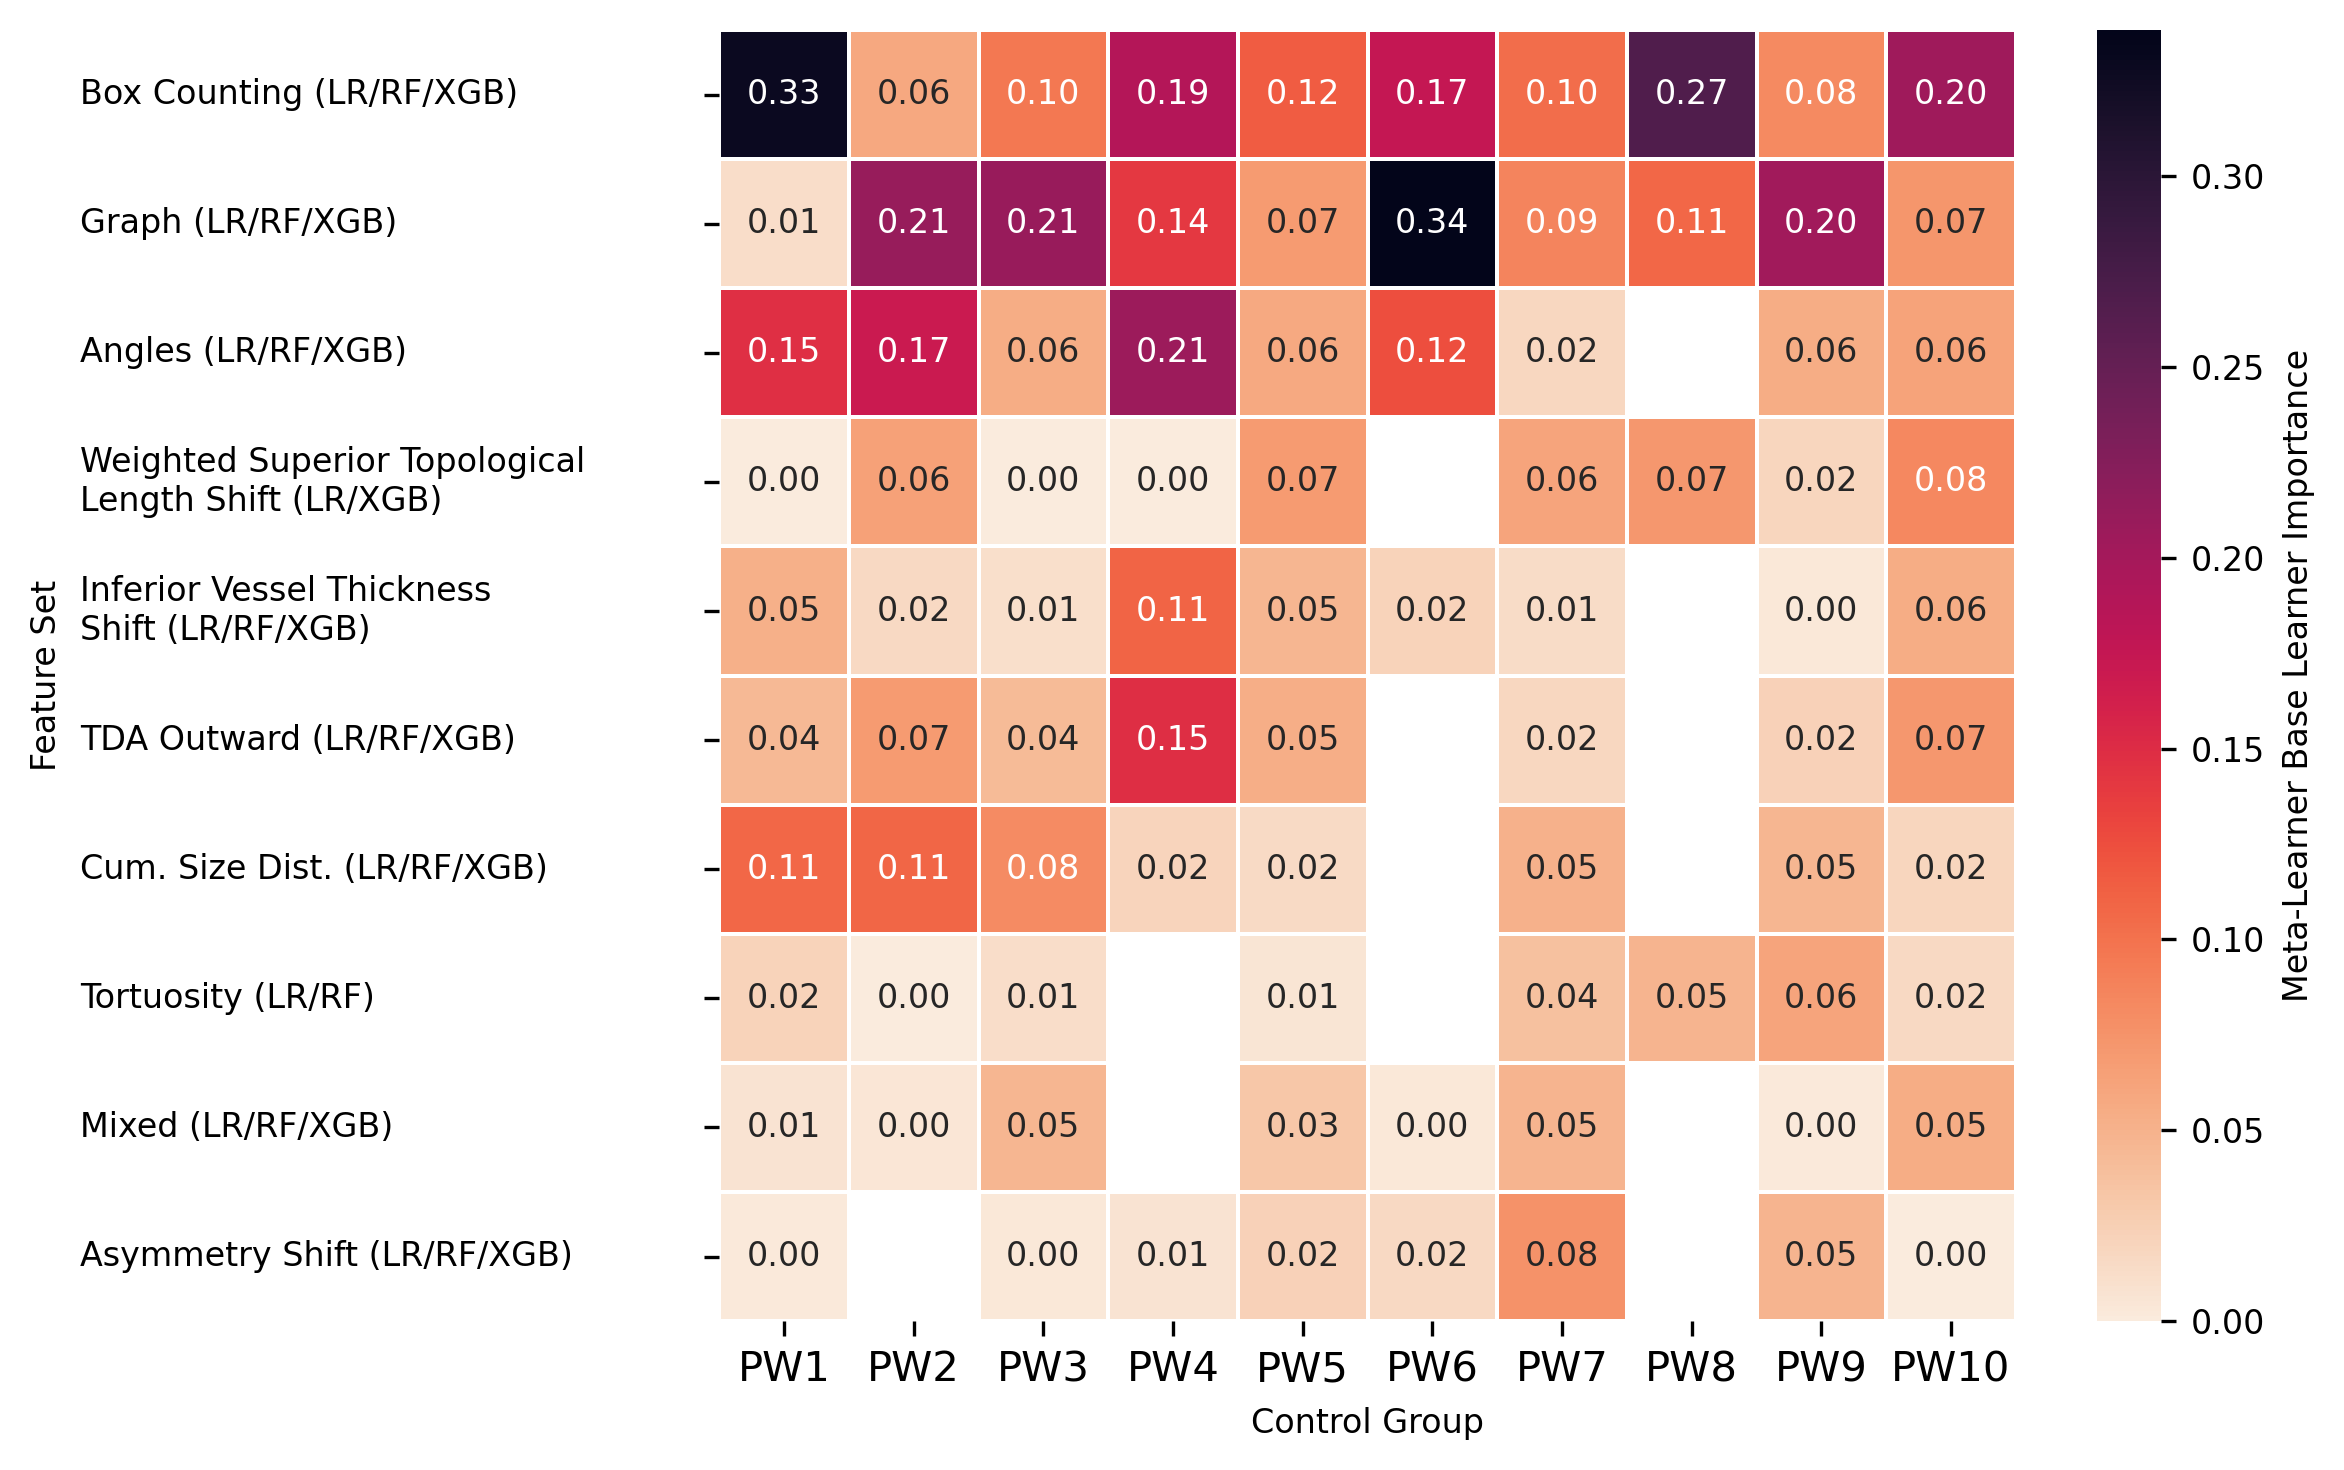

In [30]:
font_size = 12
get_test_feat_imp(test_pivot, feats=10, save_path="/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_2/c.pdf")